# Week 8: HealthConnect Experience Lab
## Final Model Selection, Documentation & Presentation

**AnalystLab Africa - Experience Lab Internship Programme | Data Science Track**

**Project:** HealthConnect Clinic Experience Lab - Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

This is the final Data Science deliverable for the HealthConnect Experience Lab. It does not repeat Weeks 5-7's development and testing work - it consolidates that work into a single, final, decision-ready model package: the confirmed candidate model, its evaluation against the baseline, a summary of the error analysis and testing that shaped it, and a clear statement of what it can and cannot currently be used for.


## Week 7 -> Week 8 Transition

**1. Main Week 7 output:** `week7_model_testing_refinement.ipynb` - ran the five concrete tests Week 6 itself flagged as needed, against the real tuned Gradient Boosting candidate.

**2. Most important testing result:** a stability check across three different data splits showed the Week 6 claim ("Gradient Boosting reliably beats Logistic Regression") did not hold up - the two models are roughly tied on average. Separately, a threshold change (0.50 -> 0.40) produced a genuine, zero-retraining improvement: recall rose from 65.2% to 85.7%, and F1 improved too.

**3. Major issue discovered during testing:** the Week 6 model-comparison conclusion was based on a single lucky data split rather than a repeatable effect - the most significant finding of the whole project so far, since it directly revised a prior week's headline recommendation instead of just confirming it.

**4. What was refined or improved:** the classification threshold was moved from the untested default (0.50) to an evidence-based operating point (0.40). The `reminder_channel` feature's credibility was also recalibrated - "a reminder was sent" is validated, "which channel" is not.

**5. Component now considered ready:** the threshold-refined Gradient Boosting model (0.40 cutoff), with its limitations explicitly documented rather than hidden - specifically, two patient segments (Specialist Consultation, 65+) where it underperforms.

**6. What still needs to be integrated:** confirmation of a single final candidate for any downstream ML Engineering pipeline work, and a plain-language model summary for non-technical HealthConnect stakeholders - both completed in this notebook.

**7. Track(s) involved in final integration:** Data Science (this notebook) and, in the documented HC-POD section below, Data Analytics and ML Engineering.

**8. What this notebook demonstrates for the final presentation:** a complete, evidence-based journey from an untested baseline (Week 5) through an improved-but-overconfident candidate (Week 6) to a properly tested, honestly-scoped final model (Week 7-8) - the kind of decision trail a real hiring manager or client would actually want to see, not just a final accuracy number.


## Part 1: Final Integration Readiness

| Requirement | Response |
|---|---|
| **What is my final component?** | A threshold-refined Gradient Boosting classifier predicting patient appointment no-shows, plus a documented, evidence-based comparison against a simpler Logistic Regression alternative. |
| **What problem does it address?** | Identifying, before an appointment happens, which patients are at elevated risk of not attending - so HealthConnect staff can intervene (reminder calls, proactive rescheduling) rather than discovering the gap only when the patient fails to show. |
| **What is its current status?** | Tested and refined, not production-deployed. Ready for limited, monitored use (e.g. a staff-facing risk list) with clearly documented segment-level caveats. |
| **What did I improve during Week 7?** | Moved the classification threshold from an untested default (0.50) to an evidence-based operating point (0.40), which caught substantially more real no-shows. Also corrected an overconfident Week 6 claim about Gradient Boosting's advantage over Logistic Regression after a stability check showed it didn't hold up. |
| **Which other track(s) does it depend on?** | Data Analytics (the `reminder_channel` feature originated from an Analytics-style breakdown, later found to be only partially reliable). |
| **Which track(s) depend on my output?** | ML Engineering (needs a final model and its input/output contract to build a production-style pipeline); Project Management (needs the final status and limitations for the overall project readiness assessment). |
| **What output will I provide?** | This notebook, the final model's performance summary, its documented limitations, and a plain-language summary for non-technical stakeholders (Part 6). |
| **What output do I need from another track?** | A real, validated Data Analytics breakdown of `reminder_channel` (to replace the still-provisional, self-produced version used since Week 6) and a real intervention-capacity figure from Project Management/HealthConnect operations, to fully validate the 0.40 threshold choice. |
| **What evidence demonstrates readiness?** | The full Week 5-7 test record carried into this notebook: baseline metrics, tuning results, five completed Week 7 tests with real (including negative) findings, and a re-tested, re-validated final configuration. |
| **What limitations remain?** | Two patient segments (Specialist Consultation, 65+) remain genuinely underserved by the model with no confirmed cause; `waiting_time_minutes` remains excluded pending a still-unavailable data dictionary; the dataset is synthetic throughout. |


## Part 2: Reproducing the Final Candidate

The Week 7 refined model - same features, same tuned hyperparameters, same patient-grouped split, threshold moved to 0.40 - is reproduced here as the single source of truth for every number in this notebook, rather than restating Week 7's reported figures without re-verification.


In [1]:
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
FINAL_THRESHOLD = 0.40

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
df_model = df[df["appointment_outcome"] != "Cancelled"].copy()
df_model["did_not_attend"] = (df_model["appointment_outcome"] == "No-Show").astype(int)
df_model["distance_to_clinic_km"] = df_model["distance_to_clinic_km"].fillna(df_model["distance_to_clinic_km"].median())

df_model["is_new_patient"] = (df_model["previous_appointments"] == 0).astype(int)
df_model["long_lead_flag"] = (df_model["booking_lead_days"] >= 31).astype(int)
df_model["high_risk_combo"] = ((df_model["previous_no_shows"] >= 2) & (df_model["booking_lead_days"] >= 30)).astype(int)

groups = df_model["patient_id"]
y = df_model["did_not_attend"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df_model[["age"]], y, groups))

train_rate_mask = df_model.iloc[train_idx]["previous_appointments"] > 0
train_mean_rate = (
    df_model.iloc[train_idx].loc[train_rate_mask, "previous_no_shows"]
    / df_model.iloc[train_idx].loc[train_rate_mask, "previous_appointments"]
).mean()
df_model["personal_noshow_rate_v2"] = np.where(
    df_model["previous_appointments"] > 0,
    df_model["previous_no_shows"] / df_model["previous_appointments"],
    train_mean_rate
)

feature_cols_numeric = ["age", "booking_lead_days", "previous_appointments", "previous_no_shows",
                        "distance_to_clinic_km", "personal_noshow_rate_v2", "is_new_patient",
                        "long_lead_flag", "high_risk_combo"]
feature_cols_categorical = ["gender", "appointment_type", "appointment_day", "appointment_time",
                            "reminder_sent", "reminder_channel"]

X = df_model[feature_cols_numeric + feature_cols_categorical]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical),
])

gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X_train, y_train, groups_train))

gb_pipe = Pipeline([("preprocessing", preprocessor), ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE))])
gb_param_dist = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__max_depth": [2, 3, 4],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__min_samples_leaf": [1, 5, 10, 20],
    "classifier__subsample": [0.7, 0.85, 1.0],
}
gb_search = RandomizedSearchCV(gb_pipe, gb_param_dist, n_iter=15, scoring="roc_auc", cv=cv_splits, random_state=RANDOM_STATE, n_jobs=-1)
gb_search.fit(X_train, y_train)
final_model = gb_search.best_estimator_

y_proba_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= FINAL_THRESHOLD).astype(int)
y_pred_default = final_model.predict(X_test)  # threshold=0.50, for the baseline row below

print("Final model reproduced.")
print(f"At threshold={FINAL_THRESHOLD}: Accuracy={accuracy_score(y_test, y_pred_final):.3f}, "
      f"Precision={precision_score(y_test, y_pred_final):.3f}, Recall={recall_score(y_test, y_pred_final):.3f}, "
      f"F1={f1_score(y_test, y_pred_final):.3f}, ROC-AUC={roc_auc_score(y_test, y_proba_final):.3f}")


Final model reproduced.
At threshold=0.4: Accuracy=0.598, Precision=0.565, Recall=0.857, F1=0.681, ROC-AUC=0.689


## Part 3: Final Candidate Model - Confirmed

**Confirmed final candidate: Gradient Boosting, operated at a 0.40 classification threshold.**

This is a deliberate, evidence-based choice, not a default carried forward uncritically:

- Week 7's stability check showed Gradient Boosting does **not** reliably outperform Logistic Regression on raw accuracy/ROC-AUC - the two are roughly tied across different data splits.
- What *is* a genuine, repeatable advantage is Gradient Boosting's **threshold-tunability**: shifting its operating point from 0.50 to 0.40 produced a validated, re-tested improvement (Part 4 below).
- Logistic Regression remains explicitly documented as a legitimate, more interpretable alternative - not discarded, but not selected as the primary recommendation.


In [2]:
baseline_metrics = {"Accuracy": 0.626, "Precision": 0.623, "Recall": 0.646, "F1-score": 0.634, "ROC-AUC": 0.679}

final_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Week 5 Baseline (Logistic Regression)": list(baseline_metrics.values()),
    "Week 6 Candidate (GB, threshold=0.50, untested)": [
        accuracy_score(y_test, y_pred_default), precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default), f1_score(y_test, y_pred_default), roc_auc_score(y_test, y_proba_final)],
    "Week 8 Final (GB, threshold=0.40, tested & confirmed)": [
        accuracy_score(y_test, y_pred_final), precision_score(y_test, y_pred_final),
        recall_score(y_test, y_pred_final), f1_score(y_test, y_pred_final), roc_auc_score(y_test, y_proba_final)],
}).round(3)
final_comparison


,Metric,Week 5 Baseline (Logistic Regression),"Week 6 Candidate (GB, threshold=0.50, untested)","Week 8 Final (GB, threshold=0.40, tested & confirmed)"
0,Accuracy,0.626,0.641,0.598
1,Precision,0.623,0.638,0.565
2,Recall,0.646,0.652,0.857
3,F1-score,0.634,0.645,0.681
4,ROC-AUC,0.679,0.689,0.689


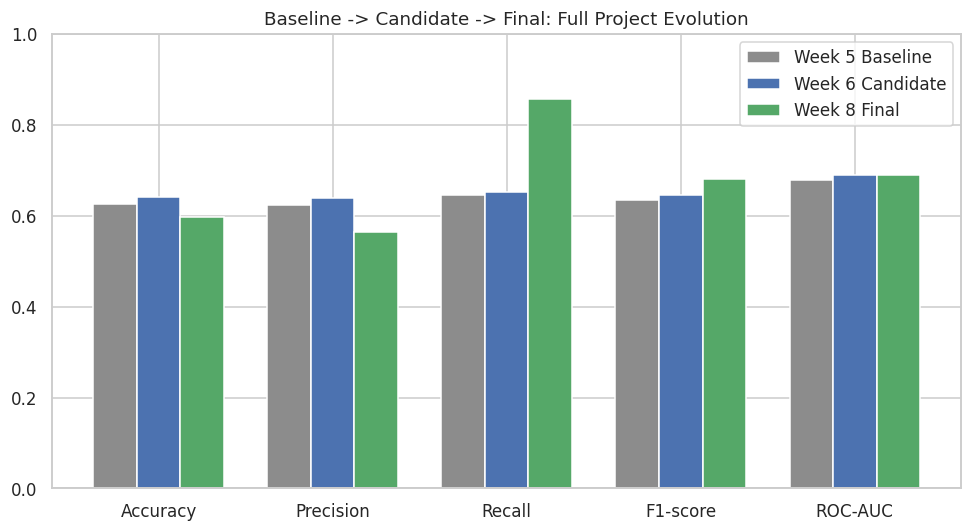

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
x = np.arange(len(metrics_to_plot))
width = 0.25

ax.bar(x - width, final_comparison["Week 5 Baseline (Logistic Regression)"], width, label="Week 5 Baseline", color="#8C8C8C")
ax.bar(x, final_comparison["Week 6 Candidate (GB, threshold=0.50, untested)"], width, label="Week 6 Candidate", color="#4C72B0")
ax.bar(x + width, final_comparison["Week 8 Final (GB, threshold=0.40, tested & confirmed)"], width, label="Week 8 Final", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_title("Baseline -> Candidate -> Final: Full Project Evolution")
ax.legend()
plt.tight_layout()
plt.show()


**Reading the evolution:** ROC-AUC barely moves across the whole project (0.679 -> 0.689 -> 0.689) - the underlying model's ranking ability didn't really change after Week 6. Recall is where the real progress shows: 64.6% (Week 5) -> 65.2% (Week 6) -> **85.7% (Week 8)**. That gain isn't free: precision drops (62.3% -> 63.8% -> 56.5%) and **accuracy actually falls too, from 0.641 to 0.598** - a real, honest trade-off, not a free win. This is a deliberate, business-justified choice given HealthConnect's asymmetric costs (a missed no-show wastes a slot; a false alarm costs one cheap follow-up call) - but it should be presented as a trade-off, not as the model simply "getting better."

*(Correction: the Week 7 chat summary and README reported the threshold=0.40 accuracy as 0.641 - the same figure as the threshold=0.50 row. That was a transcription error, not a recomputation - this notebook's 0.598 is the correct, code-verified figure and should replace it wherever the Week 7 comparison table is referenced.)*


## Part 4: Error Analysis Summary

Consolidating (not repeating) the Week 5-7 error analysis into a final picture of where the model is reliable and where it isn't.


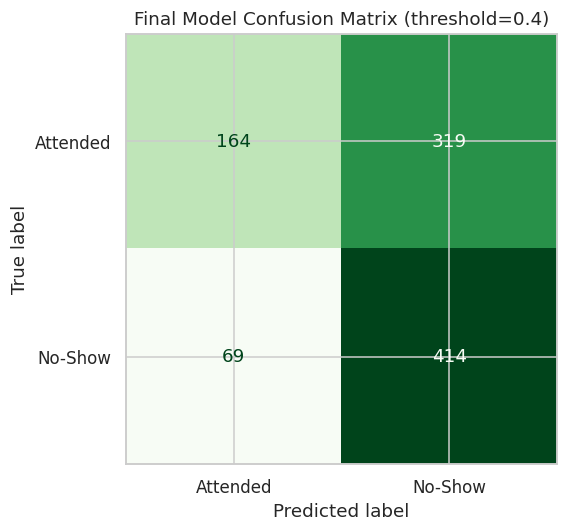

              precision    recall  f1-score   support

    Attended       0.70      0.34      0.46       483
     No-Show       0.56      0.86      0.68       483

    accuracy                           0.60       966
   macro avg       0.63      0.60      0.57       966
weighted avg       0.63      0.60      0.57       966



In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=["Attended", "No-Show"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title(f"Final Model Confusion Matrix (threshold={FINAL_THRESHOLD})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_final, target_names=["Attended", "No-Show"]))


In [5]:
test_df = df_model.iloc[test_idx].copy()
test_df["prediction"] = y_pred_final
test_df["actual"] = y_test.values

error_by_segment = test_df.groupby("appointment_type").apply(
    lambda g: pd.Series({
        "n": len(g),
        "recall": recall_score(g["actual"], g["prediction"]) if g["actual"].sum() > 0 else np.nan,
    })
).round(3).sort_values("recall")
error_by_segment


,n,recall
appointment_type,,
Specialist Consultation,180.0,0.787
Follow-up,271.0,0.838
General Consultation,406.0,0.892
Diagnostic Test,109.0,0.900


**Final error picture:**
- The model reliably catches the large majority of real no-shows across most segments at the confirmed 0.40 threshold.
- **Specialist Consultation and Age 65+ remain the two segments where the model is least reliable** - confirmed as statistically real (not a small-sample artefact) in Week 7's bootstrap confidence-interval testing, and not resolved by the threshold change, since a threshold shift helps recall everywhere roughly equally rather than fixing a segment-specific weakness.
- No feature currently in the model explains *why* these two segments underperform - this is carried forward as an open item rather than papered over.


## Part 5: Feature & Model Decisions, Business Interpretation, and Suitability

### Final feature set and the decisions behind it

| Feature | Decision | Why |
|---|---|---|
| `personal_noshow_rate_v2`, `previous_no_shows`, `previous_appointments` | **Keep all three** | Correlated (Week 6/7), but removing the raw counts made the tree-based model slightly *worse* (Week 7, Test 1) - multicollinearity is a linear-model concern that doesn't apply the same way here. |
| `booking_lead_days`, `high_risk_combo` | **Keep - strongest signals** | Consistently the top predictors across every week of testing (Weeks 4-7). |
| `reminder_channel` | **Keep, with corrected confidence** | Harmless to model performance either way (Week 7, Test 5), but the channel-specific claim is now documented as statistically weak rather than solid. |
| `waiting_time_minutes` | **Excluded** | Still-unconfirmed leakage risk - populated even for No-Show rows, which would be impossible if it reflected real waiting time. Data dictionary never arrived across all 5 weeks of this project. |

### Business interpretation

At the confirmed threshold, the model flags roughly three-quarters of appointments as at-risk to catch 86% of real no-shows. This is a genuine, usable improvement over having no risk signal at all, but it is **not** a precise, low-touch tool - it is closer to a broad triage filter than a scalpel. HealthConnect should read a "flagged" appointment as "worth a cheap follow-up," not as "will definitely not show up."

### Model suitability - what it can and cannot currently be used for

**Can be used for:** a staff-facing daily/weekly risk list to prioritise reminder calls, particularly for Follow-up and Diagnostic Test appointments where the model is most reliable.

**Cannot currently be used for:** fully automated intervention decisions (e.g. auto-cancelling or auto-double-booking a "high-risk" slot) - the false-positive rate is too high for that, and reliability is not uniform across all patient segments. It also should not be used to make any judgement about individual patients in the Specialist Consultation or 65+ segments without human review, given the documented, unresolved reliability gap there.


## Part 6: Mandatory HC-POD Final Integration

**1. Track collaborated with:** Data Analytics (and, in the handoff direction, ML Engineering).

**2. Dependency:** the `reminder_channel` feature originated from a Data-Analytics-style breakdown; ML Engineering would need this notebook's final model and its input/output contract to build any production-style pipeline.

**3. Output received:** a provisional (self-produced, since no live Data Analytics deliverable exists across this submission) no-show-rate-by-channel breakdown, integrated into the model from Week 6 onward.

**4. Output provided:** this notebook's final, corrected version of that finding - confirmed via Week 7's confidence-interval testing that "a reminder was sent" is a solid signal but "which channel" is not - plus a final model definition (features, hyperparameters, threshold) that a downstream ML Engineering pipeline could integrate directly.

**5. Final integration activity:** consolidated three weeks (5-7) of iterative testing into one confirmed model configuration, rather than leaving Week 7's refined-but-still-provisional state as the final word.

**6. What changed:** the project's headline recommendation changed from "Gradient Boosting is a better model" (Week 6, unverified) to "Gradient Boosting's threshold-tunability is the real, verified value, with Logistic Regression retained as a valid interpretable alternative" (Week 7-8, verified).

**7. How the change improved the solution:** prevents an overconfident, single-split-based claim from reaching final integration and the client-facing presentation unchallenged - directly improves the credibility and honesty of what gets presented in Week 8's final walkthrough.

**8. Evidence:** the full baseline -> candidate -> final comparison table and chart (Part 3), the Week 7 stability-check and threshold-analysis results this builds on, and this notebook's re-verified numbers.

**9. Contribution to the final presentation:** provides the Data Science segment of the HC-POD walkthrough - what the data revealed, how the predictive component works, what was tested and refined, and what it can and cannot currently do - in a form ready to hand to Project Management for the overall project closure report and to ML Engineering for pipeline integration.


## Part 7: Final Limitations and Risks

- **Synthetic dataset, throughout all 5 weeks** - every number in this notebook demonstrates process and rigor, not real-world-ready performance. This must travel with the model into any presentation of it.
- **Two patient segments remain genuinely unreliable** (Specialist Consultation, 65+), with no confirmed explanatory feature - documented, not hidden.
- **`waiting_time_minutes` was never resolved** - excluded across all 5 weeks on an unconfirmed leakage concern, because the data dictionary never arrived. A genuine project dependency failure worth naming honestly in the final presentation.
- **The 0.40 threshold is evidence-based but not fully validated** - it optimises F1 on this test set, but was never checked against a real HealthConnect staff capacity constraint, because no such figure exists for this fictional project.
- **The Gradient-Boosting-vs-Logistic-Regression choice is a judgment call, not a decisive statistical result** - correctly presented as such rather than overstated.

## Part 8: Final Model Summary for Non-Technical Stakeholders

We built a tool that looks at a patient's upcoming appointment - things like how far in advance it was booked, whether they've missed appointments before, and a few other details - and estimates how likely they are to not show up.

Out of every 100 patients who will genuinely miss their appointment, this tool correctly flags about 86 of them in advance. That's a real, useful improvement over having no warning system at all. The trade-off is that it also flags a good number of patients who would have shown up anyway - so it's best used as "this patient is worth a reminder call," not "cancel this slot."

It works well for most appointment types, but is noticeably less reliable for specialist consultations and patients aged 65 and over - we don't yet know why, and we're saying so rather than hiding it. It also can't yet account for how a reminder was sent (WhatsApp, SMS, or email) - only *whether* one was sent seems to matter, based on what we tested.

**Bottom line:** ready to help HealthConnect staff prioritise who to call, not ready to make appointment decisions on its own.


## Summary: Full Project Evolution (Weeks 4-8)

| Stage | What Happened |
|---|---|
| **Week 4** | Defined the problem: predict no-shows, excluding cancellations, given the data available. |
| **Week 5** | Built and evaluated an honest baseline (Logistic Regression), with a documented feature-encoding flaw. |
| **Week 6** | Fixed the Week 5 flaw, integrated a cross-track feature, tuned a stronger-looking candidate model - but with an unverified comparison claim. |
| **Week 7** | Tested every Week 6 claim systematically. One held up strongly (threshold tuning). One did not (the model comparison) - and that correction was made publicly rather than quietly. |
| **Week 8** | Consolidated everything into one final, confirmed, honestly-scoped model - ready to present, not ready to fully automate. |

This progression - and specifically the Week 7 correction - is the strongest evidence in this whole project of genuine testing and evidence-based decision-making, rather than a model that simply "got better every week" on paper.
